# Cuaderno 02: Modelado Supervisado

In [ ]:
import pandas as pd

df = pd.read_csv('../data/RealEstate_California_Clean.csv')

"Es importante mencionar que aplicamos un escalado de datos (StandardScaler). Sin esto, el precio habría dominado el análisis, pero gracias al escalado, el algoritmo pudo entender que la ubicación geográfica es tan importante como el valor en dólares."

El objetivo fue segmentar el mercado automáticamente basándonos en tres variables: Latitud, Longitud y Precio.

In [ ]:
# definimos X_cluster usando el 'df' que cargamos arriba
X_cluster = df[['latitude', 'longitude', 'price']]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

**Gráfico 1 :**

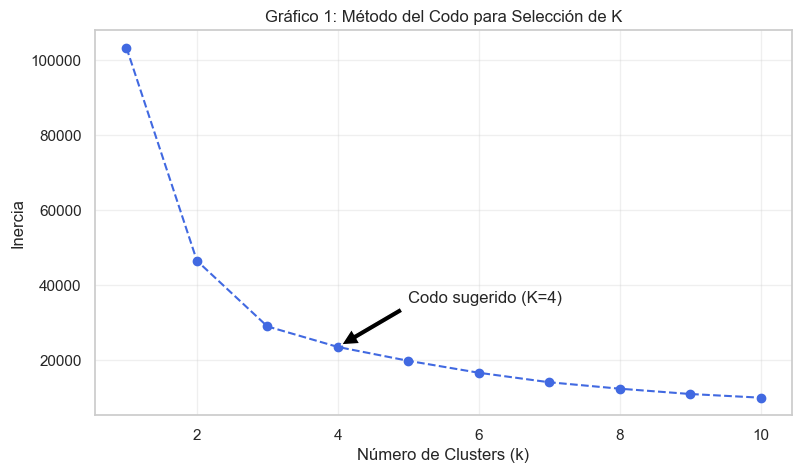

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# inercia para diferentes valores de K
inercia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled) #  datos que escale
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(K_range, inercia, marker='o', color='royalblue', linestyle='--')
plt.title('Gráfico 1: Método del Codo para Selección de K')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.annotate('Codo sugerido (K=4)', xy=(4, inercia[3]), xytext=(5, inercia[3]*1.5),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.grid(True, alpha=0.3)
plt.show()

* La línea azul representa la Inercia (o WCSS), que es la suma de las distancias al cuadrado entre cada punto y el centro de su grupo.

**Explicación:** "Buscamos el punto donde la curva se flexiona drásticamente (el 'codo'). A partir de $k=3$ o $k=4$, añadir más grupos ya no reduce significativamente la inercia. Elegimos 4 clusters porque ofrece el mejor balance entre simplicidad y precisión, evitando que el modelo se vuelva demasiado complejo (overfitting)".

**Gráfico 2 :**

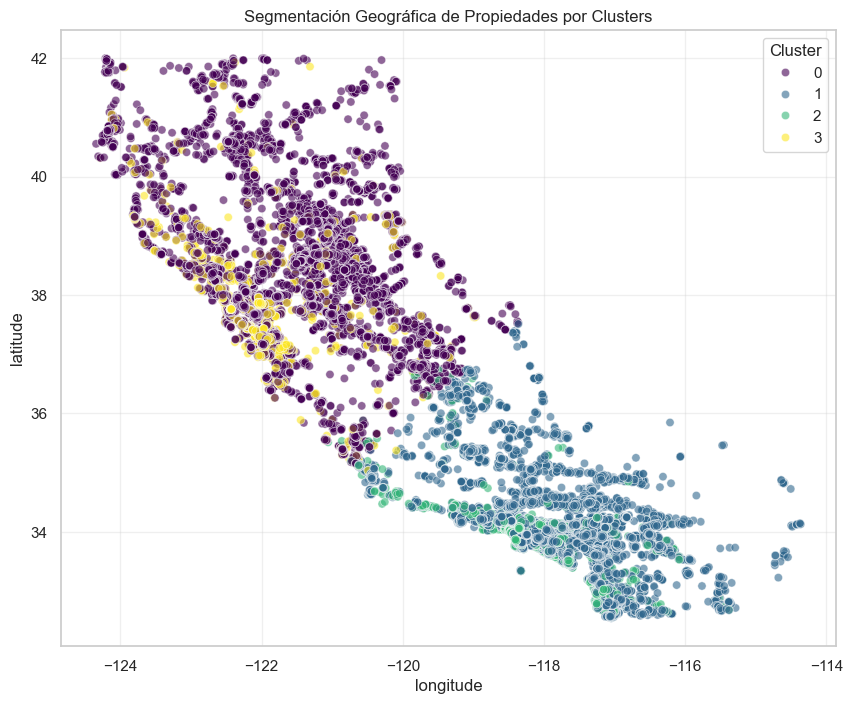

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster_zona'] = kmeans_final.fit_predict(X_scaled)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df, 
    x='longitude', 
    y='latitude', 
    hue='cluster_zona', 
    palette='viridis', 
    alpha=0.6 
)

plt.title('Segmentación Geográfica de Propiedades por Clusters')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3) 
plt.show()

In [11]:
resumen_clusters = df.groupby('cluster_zona')['price'].agg(['mean', 'count', 'std']).reset_index()

resumen_clusters.columns = ['Cluster', 'Precio Promedio', 'Cantidad de Casas', 'Desviación Estándar']

pd.options.display.float_format = '{:,.2f}'.format

print("--- Tabla de Resumen por Cluster ---")
display(resumen_clusters)

#tabla en un CSV 
resumen_clusters.to_csv('../data/resumen_estadistico_clusters.csv', index=False)

--- Tabla de Resumen por Cluster ---


,Cluster,Precio Promedio,Cantidad de Casas,Desviación Estándar
0,0,"592,138.84",12744,"362,143.83"
1,1,"652,506.75",16523,"387,064.19"
2,2,"2,647,320.14",2513,"867,905.96"
3,3,"2,346,309.52",2640,"855,379.02"


Ahora entendemos que el mercado inmobiliario de California está fuertemente dividido por zonas de valor geográfico.

* Los Clusters 0 y 1 representan el mercado masivo, con casi 30.000 propiedades de precios accesibles distribuidas por todo el estado.

* Los Clusters 2 y 3 logran aislar los nichos de lujo. Aunque son pocos puntos en el mapa, su valor promedio supera los 2.3 millones de dólares, concentrándose principalmente en la franja costera.

* Los colores que está muy amontonado el modelo agrupó estas casas porque comparten una densidad urbana y rangos de precios similares

* La desviación estándar en los clusters de lujo (2 y 3) es más alta, indica que en el segmento premium hay mucha más variedad de precios (desde mansiones caras hasta propiedades extremas) comparado con el mercado estándar.